In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from torchmetrics import MeanAbsolutePercentageError, MeanAbsoluteError
import dask.dataframe as dd
import glob

device = torch.device('cuda')

# Define the SelfAttention class
class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads, seq_len, module, rel_emb):
        super(SelfAttention, self).__init__()
        self.device = torch.device('cuda')
        self.embed_size = embed_size
        self.heads = heads
        self.seq_len = seq_len
        self.module = module
        self.rel_emb = rel_emb
        modules = ['spatial', 'temporal', 'spatiotemporal', 'output']
        assert (modules.__contains__(module)), "Invalid module"


        if module == 'spatial' or module == 'temporal':
            self.head_dim = seq_len
            self.values = nn.Linear(self.embed_size, self.embed_size, dtype=torch.float32)
            self.keys = nn.Linear(self.embed_size, self.embed_size, dtype=torch.float32, device=self.device)
            self.queries = nn.Linear(self.embed_size, self.embed_size, dtype=torch.float32, device=self.device)

            if rel_emb:
                self.E = nn.Parameter(torch.randn([self.heads, self.head_dim, self.embed_size], device=self.device))


        else:
            self.head_dim = embed_size // heads
            assert (self.head_dim * heads == embed_size), "Embed size not div by heads"
            self.values = nn.Linear(self.head_dim, self.head_dim, dtype=torch.float32)
            self.keys = nn.Linear(self.head_dim, self.head_dim, dtype=torch.float32, device=self.device)
            self.queries = nn.Linear(self.head_dim, self.head_dim, dtype=torch.float32, device=self.device)

            if rel_emb:
                self.E = nn.Parameter(torch.randn([1, self.seq_len, self.head_dim], device=self.device))

        self.fc_out = nn.Linear(self.embed_size, self.embed_size, device=self.device)

    def forward(self, x):
        N, _, _ = x.shape

        #non-shared weights between heads for spatial and temporal modules
        if self.module == 'spatial' or self.module == 'temporal':
            values = self.values(x)
            keys = self.keys(x)
            queries = self.queries(x)
            values = values.reshape(N, self.seq_len, self.heads, self.embed_size)
            keys = keys.reshape(N, self.seq_len, self.heads, self.embed_size)
            queries = queries.reshape(N, self.seq_len, self.heads, self.embed_size)

        #shared weights between heads for spatio-temporal module
        else:
            values, keys, queries = x, x, x
            values = values.reshape(N, self.seq_len, self.heads, self.head_dim)
            keys = keys.reshape(N, self.seq_len, self.heads, self.head_dim)
            queries = queries.reshape(N, self.seq_len, self.heads, self.head_dim)
            values = self.values(values)
            keys = self.keys(keys)
            queries = self.queries(queries)


        if self.rel_emb:
            QE = torch.matmul(queries.transpose(1, 2), self.E.transpose(1,2))
            QE = self._mask_positions(QE)
            S = self._skew(QE).contiguous().view(N, self.heads, self.seq_len, self.seq_len)
            qk = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
            mask = torch.triu(torch.ones(1, self.seq_len, self.seq_len, device=self.device),
                    1)
            if mask is not None:
                qk = qk.masked_fill(mask == 0, float("-1e4"))

            attention = torch.softmax(qk / (self.embed_size ** (1/2)), dim=3) + S

        else:
            qk = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
            mask = torch.triu(torch.ones(1, self.seq_len, self.seq_len, device=self.device),
                    1)
            if mask is not None:
                qk = qk.masked_fill(mask == 0, float("-1e4"))

            attention = torch.softmax(qk / (self.embed_size ** (1/2)), dim=3)

        #attention(N x Heads x Q_Len x K_len)
        #values(N x V_len x Heads x Head_dim)
        #z(N x Q_len x Heads*Head_dim)

        if self.module == 'spatial' or self.module == 'temporal':
            z = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(N, self.seq_len*self.heads, self.embed_size)
        else:
            z = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(N, self.seq_len, self.heads*self.head_dim)

        z = self.fc_out(z)

        return z


    def _mask_positions(self, qe):
        L = qe.shape[-1]
        mask = torch.triu(torch.ones(L, L, device=self.device), 1).flip(1)
        return qe.masked_fill((mask == 1), 0)

    def _skew(self, qe):
        #pad a column of zeros on the left
        padded_qe = F.pad(qe, [1,0])
        s = padded_qe.shape
        padded_qe = padded_qe.view(s[0], s[1], s[3], s[2])
        #take out first (padded) row
        return padded_qe[:,:,1:,:]

class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, seq_len, module, forward_expansion, rel_emb):
        super(TransformerBlock, self).__init__()
        self.attention = SelfAttention(embed_size, heads, seq_len, module, rel_emb)
        if module == 'spatial' or module == 'temporal':
            self.norm1 = nn.BatchNorm1d(seq_len * heads)
            self.norm2 = nn.BatchNorm1d(seq_len * heads)
        else:
            self.norm1 = nn.BatchNorm1d(seq_len)
            self.norm2 = nn.BatchNorm1d(seq_len)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.LeakyReLU(),
            nn.Linear(forward_expansion * embed_size, embed_size)
        )

    def forward(self, x):
        attention = self.attention(x)
        x = self.norm1(attention + x)
        forward = self.feed_forward(x)
        out = self.norm2(forward + x)
        return out

class Encoder(nn.Module):
    def __init__(self, seq_len, embed_size, num_layers, heads, device, forward_expansion, module, output_size=1, rel_emb=True):
        super(Encoder, self).__init__()
        self.module = module
        self.embed_size = embed_size
        self.device = device
        self.rel_emb = rel_emb
        self.fc_out = nn.Linear(embed_size, embed_size)
        self.layers = nn.ModuleList([
            TransformerBlock(embed_size, heads, seq_len, module, forward_expansion, rel_emb)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        out = self.fc_out(x)
        return out

class Transformer(nn.Module):
    def __init__(self, input_shape, output_size,
                 embed_size, num_layers, forward_expansion, heads):

        super(Transformer, self).__init__()
        self.batch_size, self.num_var, self.seq_len = input_shape
        self.device = torch.device('cuda')
        self.num_elements = self.seq_len*self.num_var
        self.embed_size = embed_size
        self.element_embedding = nn.Linear(self.seq_len, embed_size*self.seq_len)
        self.pos_embedding = nn.Embedding(self.seq_len, embed_size)
        self.variable_embedding = nn.Embedding(self.num_var, embed_size)


        self.temporal = Encoder(seq_len=self.seq_len,
                                embed_size=embed_size,
                                num_layers=num_layers,
                                heads=self.num_var,
                                device=self.device,
                                forward_expansion=forward_expansion,
                                module='temporal',
                                rel_emb=True)

        self.spatial = Encoder(seq_len=self.num_var,
                               embed_size=embed_size,
                               num_layers=num_layers,
                               heads=self.seq_len,
                               device=self.device,
                               forward_expansion=forward_expansion,
                               module = 'spatial',
                               rel_emb=True)

        self.spatiotemporal = Encoder(seq_len=self.seq_len*self.num_var,
                                      embed_size=embed_size,
                                      num_layers=num_layers,
                                      heads=heads,
                                      device=self.device,
                                      forward_expansion=forward_expansion,
                                      module = 'spatiotemporal',
                                      rel_emb=True)


        # consolidate embedding dimension
        self.fc_out1 = nn.Linear(embed_size, embed_size//2)
        self.fc_out2 = nn.Linear(embed_size//2, 1)

        #prediction
        self.out = nn.Linear((self.num_elements*3), output_size)


    def forward(self, x, dropout=0.1):
        batch_size = len(x)

        #process/embed input for temporal module
        positions = torch.arange(0, self.seq_len).expand(batch_size, self.num_var, self.seq_len).reshape(batch_size, self.num_var * self.seq_len).to(self.device)
        x_temporal = self.element_embedding(x).reshape(batch_size, self.num_elements, self.embed_size)
        x_temporal = F.dropout(self.pos_embedding(positions) + x_temporal, dropout)

        #process/embed input for spatial module
        x_spatial = torch.transpose(x, 1, 2).reshape(batch_size, self.num_var, self.seq_len)
        vars = torch.arange(0, self.num_var).expand(batch_size, self.seq_len, self.num_var).reshape(batch_size, self.num_var * self.seq_len).to(self.device)
        x_spatial = self.element_embedding(x_spatial).reshape(batch_size, self.num_elements, self.embed_size)
        x_spatial = F.dropout(self.variable_embedding(vars) + x_spatial, dropout)

        #process/embed input for spatio-temporal module
        positions = torch.arange(0, self.seq_len).expand(batch_size, self.num_var, self.seq_len).reshape(batch_size, self.num_var* self.seq_len).to(self.device)
        x_spatio_temporal = self.element_embedding(x).reshape(batch_size, self.seq_len* self.num_var, self.embed_size)
        x_spatio_temporal = F.dropout(self.pos_embedding(positions) + x_spatio_temporal, dropout)

        out1 = self.temporal(x_temporal)
        out2 = self.spatial(x_spatial)
        out3 = self.spatiotemporal(x_spatio_temporal)
        out = torch.cat((out1, out2, out3), 1)
        out = self.fc_out1(out)
        out = F.leaky_relu(out)
        out = self.fc_out2(out)
        out = F.leaky_relu(out)
        out = torch.flatten(out, 1)
        out = self.out(out)
        return out

# Data processing and loading
class CustomDataset(Dataset):
    def __init__(self, data_files, target_variable):
        self.data_files = data_files
        self.target_variable = target_variable
        self.data = self.load_data()
        # Extract the number of variables and sequence length from the data
        self.num_var = len(self.data.columns) - 1 # Subtract 1 for the target variable
        self.seq_len = 1  # Adjust if you have actual sequence length

    def load_data(self):
        ddf = dd.read_csv(self.data_files, assume_missing=True)
        df = ddf
        df['Longitude'] = df['Longitude'] + df['S-Mean Longitude']
        df['Latitude'] = df['Latitude'] + df['S-Mean Latitude']
        df['Longitude'] = df['Longitude'].apply(lambda x: x - 360 if x > 180 else x, meta=('x', 'f8'))
        df['Year/Month'] = dd.to_datetime(df['Year/Month'], format='%Y/%m')
        df['Year'] = df['Year/Month'].dt.year
        df['Month'] = df['Year/Month'].dt.month
        df = df.drop(columns=['Year/Month'])
        df = df[df['Longitude'] >= -80]
        df = df[df['Longitude'] <= -10]
        df = df[df['Latitude'] >= 0]
        df = df.dropna()
        df = df.compute()
        print(df.shape)
        df = df[['Year', 'Month', 'Longitude', 'Latitude', 'S-Mean',
                #'A-Mean', 'Q-Mean', 'R-Mean_x', 
                #'W-Mean', 'U-Mean', 'V-Mean', 'P-Mean', 
                #'C-Mean', 
                #'X=W*U-Mean', 'Y=W*V-Mean', 
                #'D=S-A-Mean', 'E=(S-A)*W-Mean', 'F=QS-Q-Mean', 'G=(QS-Q)*W-Mean',
                #'I=U*A-Mean', 'J=V*A-Mean', 'K=U*Q-Mean', 'L=V*Q-Mean',
                #'M=(QS-Q)*U-Mean', 'N=(QS-Q)*V-Mean', 
                #'B1=W*W*W-Mean', 'B2=W*W*W-Mean'
               ]]
        return df

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        x = row.drop(self.target_variable).values
        x = x.reshape((self.num_var, self.seq_len))  # Ensure this reshape fits your data
        y = row[self.target_variable]
        return torch.tensor(x, dtype=torch.float32), torch.tensor([y], dtype=torch.float32)  # Ensure y is a tensor of shape [1]


data_files = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.0/combined/*.csv'
target_variable = 'S-Mean'
dataset = CustomDataset(data_files, target_variable)

(944476, 204)


In [4]:
import os
import torch.optim as optim
import torch.cuda.amp as amp
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

# DataLoader setup
batch_size = 32
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_indices = list(range(train_size))
test_indices = list(range(train_size, len(dataset)))

train_sampler = SubsetRandomSampler(train_indices)
test_sampler = SubsetRandomSampler(test_indices)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

# Model initialization
input_shape = (batch_size, len(dataset.data.columns) - 1, 1) # Adjust shape as necessary
output_size = 1
embed_size = 512
num_layers = 4
forward_expansion = 4
heads = 16

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

model = Transformer(input_shape, output_size, embed_size, num_layers, forward_expansion, heads).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler: Reduce LR on plateau (e.g., when validation loss doesn't improve)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Training loop with Mixed Precision and LR Scheduler
epochs = 100
dropout = 0.1
best_test_loss = float('inf')
epochs_without_improvement = 0
patience = 10

/home/innobridge/.local/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100, Train Loss: 1.0185, Test Loss: 1.3582
Epoch 2/100, Train Loss: 1.0092, Test Loss: 1.5204
Epoch 3/100, Train Loss: 0.9959, Test Loss: 1.4745
Epoch 4/100, Train Loss: 0.9774, Test Loss: 1.4301
Epoch 5/100, Train Loss: 0.9707, Test Loss: 1.4221
Epoch 6/100, Train Loss: 0.9533, Test Loss: 1.4760
Epoch 7/100, Train Loss: 0.9477, Test Loss: 1.7587
Early stopping triggered!
Training complete!


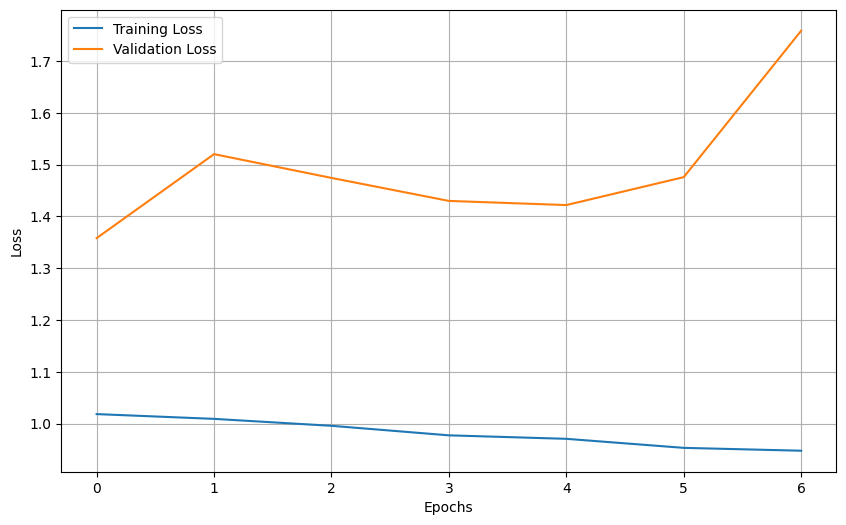

In [4]:
import matplotlib.pyplot as plt

# Initialize lists to store the loss values
train_losses = []
test_losses = []

# Training loop
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data, dropout)
        target = target.view(-1, 1)  # Make sure target has shape (batch_size, 1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)  # Store the training loss

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data, dropout)
            target = target.view(-1, 1)  # Ensure target shape matches output shape
            loss = criterion(output, target)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    test_losses.append(test_loss)  # Store the test loss

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_without_improvement = 0
        torch.save(model, 'Transformer 9-23.pt')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered!")
        break

print("Training complete!")

# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
output_file_name = f"train (9-23).png"
folder_path = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/'
output_path = os.path.join(folder_path, output_file_name)
plt.savefig(output_path)
print(f"Saved {output_file_name}")
plt.close()

import os
import torch
import numpy as np
import csv
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Load the trained model
model = torch.load('Transformer 9-23.pt')
model.eval()  # Set the model to evaluation mode

def custom_coolwarm():
    coolwarm = plt.cm.coolwarm
    colors = coolwarm(np.linspace(0.1, 1, 256))
    return LinearSegmentedColormap.from_list('custom_coolwarm', colors)

# Function to prepare input data for prediction
def prepare_input_data(year, month, lons, lats):
    inputs = []
    for lon, lat in zip(lons, lats):
        inputs.append([year, month, lon, lat])
    inputs = np.array(inputs)
    return torch.tensor(inputs, dtype=torch.float32)

# Function to generate predictions
def generate_predictions(model, year, month, lons, lats, batch_size=32):
    predictions = []
    model = model.to(device)
    with torch.no_grad():
        for i in range(0, len(lons), batch_size):
            batch_lons = lons[i:i + batch_size]
            batch_lats = lats[i:i + batch_size]
            inputs = prepare_input_data(year, month, batch_lons, batch_lats).to(device)
            inputs = inputs.view(-1, len(inputs[0]), 1)  # Reshape to match model input
            preds = model(inputs, dropout=0).cpu().numpy()
            predictions.extend(preds.flatten())
    return np.array(predictions)

# Function to save predictions to a CSV file
def save_predictions_to_csv(predictions, lons, lats, year, month, output_dir):
    csv_file = os.path.join(output_dir, f"Transformer_9-23_{year}.{month}.csv")
    with open(csv_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Year", "Month", "Longitude", "Latitude", "S-Mean"])
        for lon, lat, pred in zip(lons, lats, predictions):
            writer.writerow([year, month, lon, lat, pred])
    print(f"CSV saved: {csv_file}")

# Directory to save CSV files
output_dir = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/'  # Change to the actual path

# Function to plot predictions
def plot_predictions(predictions, lons, lats, year, month):

    # Reshape predictions back into grid format
    lon_grid = np.reshape(lons, (180, 360))  # Assuming 1-degree intervals
    lat_grid = np.reshape(lats, (180, 360))
    pred_grid = np.reshape(predictions, (180, 360))
    
    # Initialize the map with cartopy and plot the predictions
    fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Adding map features (coastlines, borders, ocean, land, etc.)
    ax.coastlines(zorder=6)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.OCEAN, color='lightblue', zorder=2)
    ax.add_feature(cfeature.LAND, color='lightgreen', edgecolor='black', zorder=4)
    ax.add_feature(cfeature.LAKES, edgecolor='black', zorder=6)
    ax.add_feature(cfeature.RIVERS, zorder=5)
    ax.set_extent([-80, -10, 0, 90])

    # Scatter plot for the predictions
    scatter = ax.scatter(lons, lats, c=predictions, cmap=custom_coolwarm(), s=150, transform=ccrs.PlateCarree(), vmin=-6, vmax=36, zorder=2)

    contour = plt.contour(lon_grid, lat_grid, pred_grid, linestyles="dashed", levels=[12], colors='black', transform=ccrs.PlateCarree(), zorder=3)
    ax.clabel(contour, colors=['black'], inline=True, fmt=' {:.0f} '.format, zorder=4)
    
    cbar = plt.colorbar(scatter, label='Mean SST °C')
    cbar.set_ticks([-6, -3, 0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36])
    cbar.set_ticklabels(['-6', '-3', '0', '3', '6', '9', '12', '15', '18', '21', '24', '27', '30', '33', '36'])
    
    # Set title and labels
    plt.rcParams.update({'font.size': 24})
    plt.rcParams.update({'font.family': 'sans-serif'})
    plt.title(f'Predicted Mean SST Distribution - {year}/{month}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)

    # Save the plot
    folder_path = '/mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/'
    output_path = os.path.join(folder_path, f"Transformer_9-23_{year}.{month}.png")
    plt.savefig(output_path)
    print(f"Saved Transformer_9-23_{year}.{month}.png")
    
    # Close the plot to release memory
    plt.close()

# For scatter
# Generate a grid of longitudes and latitudes
lons = np.arange(-180, 180, 1)  # 1-degree intervals across longitudes
lats = np.arange(-90, 90, 1)    # 1-degree intervals across latitudes
lon_grid, lat_grid = np.meshgrid(lons, lats)
lon_grid_flat = lon_grid.flatten()
lat_grid_flat = lat_grid.flatten()

# For contour
# Create latitude and longitude values (for the shape of Earth)
latitudes = np.linspace(-90, 90, 180)  # 180 points from -90 to 90 (for latitude)
longitudes = np.linspace(-180, 180, 360)  # 360 points from -180 to 180 (for longitude)
# Create meshgrid for plotting
lon_gridc, lat_gridc = np.meshgrid(longitudes, latitudes)

for year in range(2014, 2101):
    for month in range(1, 13):
        # Generate predictions for the entire grid
        predictions = generate_predictions(model, year, month, lon_grid_flat, lat_grid_flat)

        save_predictions_to_csv(predictions, lon_grid_flat, lat_grid_flat, year, month, output_dir)
        
        # Plot the predictions
        plot_predictions(predictions, lon_grid_flat, lat_grid_flat, year, month)

Saved train (9-23).png


/tmp/ipykernel_337527/410884019.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('Transformer 9-23.pt')


CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_9-23_2014.1.csv
Saved Transformer_9-23_2014.1.png
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_9-23_2014.2.csv
Saved Transformer_9-23_2014.2.png
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_9-23_2014.3.csv
Saved Transformer_9-23_2014.3.png
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_9-23_2014.4.csv
Saved Transformer_9-23_2014.4.png
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_9-23_2014.5.csv
Saved Transformer_9-23_2014.5.png
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_9-23_2014.6.csv
Saved Transformer_9-23_2014.6.png
CSV saved: /mnt/c/Users/aardp/Downloads/OJ/cleaned_csv/R3.0.2/combined/Transformer_9-23/Transformer_